In [6]:
import pandas as pd

df = pd.read_csv('train.csv', parse_dates=['date'])

In [7]:
import numpy as np

def build_leakage_safe_features(df: pd.DataFrame) -> pd.DataFrame:

    #Guarantee strict chronological ordering within each series
    df = df.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

    grouped = df.groupby(['store_nbr', 'family'])['sales']

    #Lag Features
    # Explicitly grouped shifts prevent cross-series data pollution
    df['sales_lag_1'] = grouped.shift(1)
    df['sales_lag_7'] = grouped.shift(7)
    df['sales_lag_28'] = grouped.shift(28)

    #Rolling Statistics
    # CRITICAL: .shift(1) moves the window strictly into the past
    past_sales = grouped.shift(1)

    # Rolling 7-day stats
    df['sales_rolling_mean_7'] = past_sales.groupby([df['store_nbr'], df['family']]).rolling(window=7, min_periods=7).mean().reset_index(drop=True)
    df['sales_rolling_std_7'] = past_sales.groupby([df['store_nbr'], df['family']]).rolling(window=7, min_periods=7).std().reset_index(drop=True)

    # Rolling 28-day stats
    df['sales_rolling_mean_28'] = past_sales.groupby([df['store_nbr'], df['family']]).rolling(window=28, min_periods=28).mean().reset_index(drop=True)
    df['sales_rolling_std_28'] = past_sales.groupby([df['store_nbr'], df['family']]).rolling(window=28, min_periods=28).std().reset_index(drop=True)

    return df

# Verification test: Manual row trace
def verify_leakage_safety(df: pd.DataFrame, sample_idx: int = 40):
    row = df.iloc[sample_idx]
    current_date = row['date']
    store = row['store_nbr']
    family = row['family']

    print(f"--- Verification for Date: {current_date} (Store: {store}, Family: {family}) ---")
    print(f"Actual current sales (Day D): {row['sales']}")
    print(f"sales_lag_1: {row['sales_lag_1']}")
    print(f"sales_rolling_mean_7: {row['sales_rolling_mean_7']}")

    # Raw historical sales strictly prior to Date D
    history = df[(df['store_nbr'] == store) & 
                 (df['family'] == family) & 
                 (df['date'] < current_date)].tail(7)
    
    assert row['sales_lag_1'] == history['sales'].iloc[-1], "Lag 1 mismatch!"
    assert np.isclose(row['sales_rolling_mean_7'], history['sales'].mean()), "Rolling mean mismatch!"
    print("Leakage verification passed: No row from date >= D entered the feature set.")

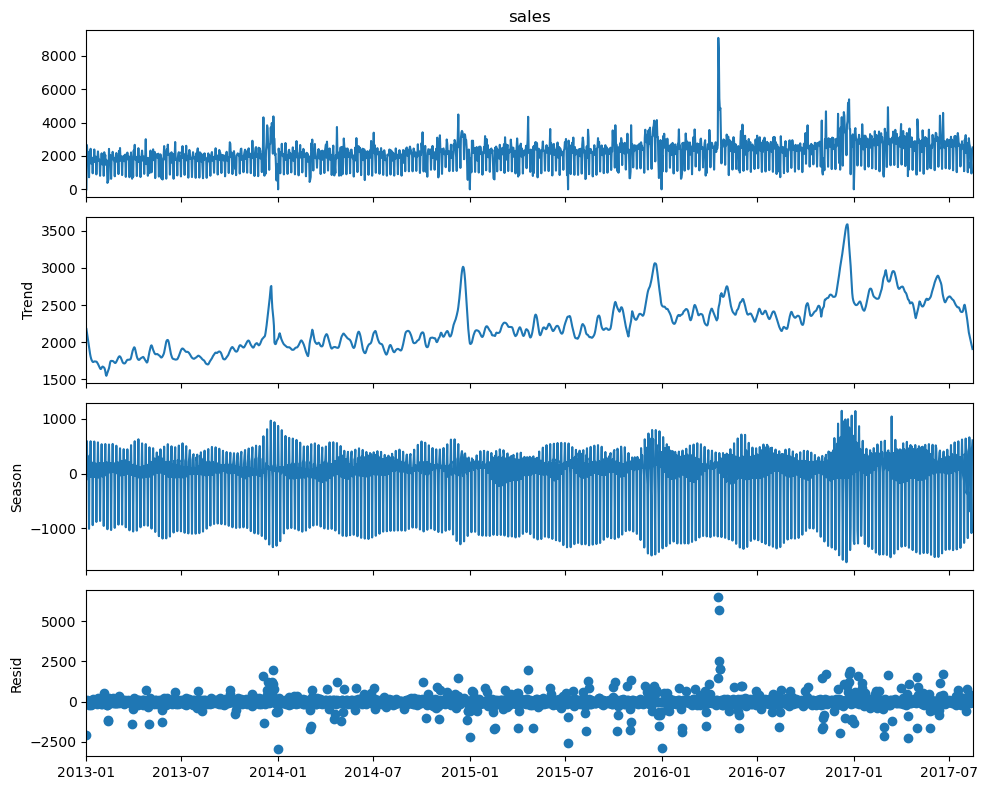

In [8]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# Select a high-volume, continuous store/family series
sample_series = df[(df['store_nbr'] == 1) & (df['family'] == 'GROCERY I')].copy()
sample_series = sample_series.set_index('date')['sales'].asfreq('D')

# Fill occasional store closure/holiday gaps if needed
sample_series = sample_series.ffill()

# STL handles non-linear trends and changing seasonality robustly
stl = STL(sample_series, period=7, robust=True)  # 7-day period for day-of-week seasonality
res = stl.fit()

# Plot decomposition
fig = res.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

In [9]:
# if i shift the eniter column without using grouby, store b accidentally gets sales data from store A, mixing completely  different stores together
# if i calculate rolling averages without using shift(1_ first the current day's sales get included in its own average. which leaks future answer into my 
# training data which wont exist at prediction time and will make my model fail in real world. enforcing strict shifts ensures the model only ever looks
# at past
